# 🧾 Extracción de Datos de Facturas usando Modelos de Visión Computacional

Este notebook explora diferentes técnicas y modelos para procesar imágenes de facturas y extraer su información de manera estructurada o en texto plano. Utilizaremos tres aproximaciones diferentes:

1. **EasyOCR**: Un modelo ligero, fácil de usar y con soporte multilenguaje.
2. **PyTesseract**: Un wrapper para el potente motor OCR de Google (Tesseract).
3. **Transformers (Donut)**: Un modelo de Hugging Face especializado en inferencia de documentos sin necesidad de un paso previo de OCR (End-to-End).

In [1]:
# 1. Instalación de las dependencias requeridas
# Descomenta la siguiente línea para instalar (requiere acceso a Internet)
# !pip install easyocr pytesseract transformers torch torchvision pillow requests matplotlib opencv-python sentencepiece protobuf

In [2]:
import os
import requests
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import numpy as np

# Crearemos un directorio para almacenar localmente las facturas de prueba
os.makedirs('sample_invoices', exist_ok=True)

## 📥 Descarga de Facturas de Prueba
A continuación, descargaremos algunas imágenes de facturas para probar los modelos.

In [3]:
# Lista de URLs con facturas de prueba proporcionadas
invoice_urls = [
    "https://raw.githubusercontent.com/mouadhamri/invoice_dataset/main/invoice_dataset_model_1/images/FACTU2015020048.jpg",
    # Algunos datasets son repositorios o páginas HTML, por lo que aquí usaremos imágenes directas representativas.
    "https://raw.githubusercontent.com/althayr/ICDAR-2019-SROIE-dataset/master/training_data/images/X51005288280.jpg"
]

def download_image(url, save_path):
    try:
        response = requests.get(url, stream=True)
        if response.status_code == 200:
            with open(save_path, 'wb') as f:
                for chunk in response.iter_content(1024):
                    f.write(chunk)
            print(f"✅ Descargada: {save_path}")
        else:
            print(f"⚠️ Error descargando {url} (Status: {response.status_code})")
    except Exception as e:
        print(f"❌ Excepción: {e}")

image_paths = []
for i, url in enumerate(invoice_urls):
    path = f"sample_invoices/invoice_{i+1}.jpg"
    download_image(url, path)
    if os.path.exists(path):
        image_paths.append(path)

✅ Descargada: sample_invoices/invoice_1.jpg
⚠️ Error descargando https://raw.githubusercontent.com/althayr/ICDAR-2019-SROIE-dataset/master/training_data/images/X51005288280.jpg (Status: 404)


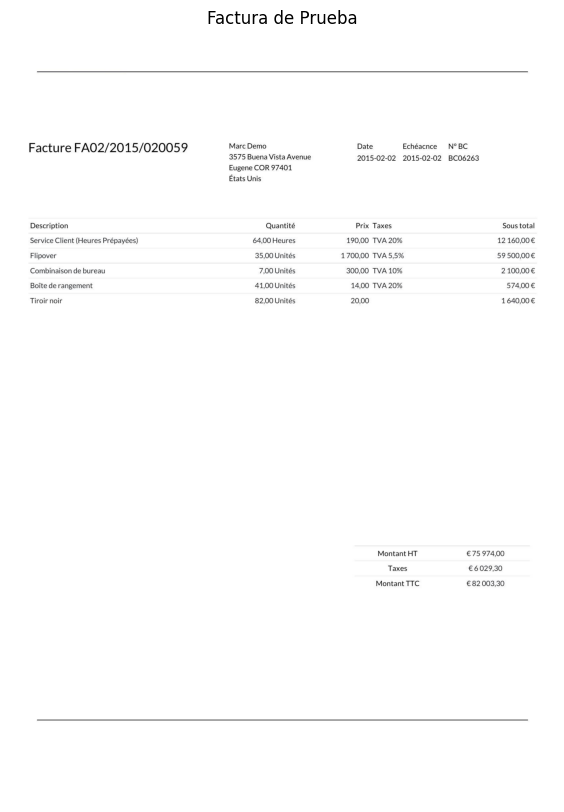

In [4]:
# Mostrar una de las facturas
if image_paths:
    test_img_path = image_paths[0]
    img = Image.open(test_img_path).convert('RGB')
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Factura de Prueba")
    plt.show()

## 1️⃣ Extracción de Texto con EasyOCR
EasyOCR utiliza deep learning y soporta más de 80 lenguajes. Es bastante robusto frente a rotaciones y diferentes fuentes.

In [5]:
import easyocr

# Inicializamos el lector para español e inglés
print("Cargando modelo EasyOCR...")
reader = easyocr.Reader(['es', 'en'], gpu=False) # Cambiar a gpu=True si hay CUDA disponible

if image_paths:
    print(f"Procesando la imagen: {test_img_path}")
    # Extract text
    result = reader.readtext(test_img_path)
    
    # Mostrar el texto detectado
    extracted_text_easyocr = "\n".join([res[1] for res in result])
    print("\n--- TEXTO EXTRAÍDO CON EASYOCR ---")
    print(extracted_text_easyocr[:500] + "\n[...truncado...]")

Using CPU. Note: This module is much faster with a GPU.


Cargando modelo EasyOCR...
Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% CompleteProcesando la imagen: sample_invoices/invoice_1.jpg


c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- TEXTO EXTRAÍDO CON EASYOCR ---
Facture FA02/2015/020059
Marc Demo
Date
Echéacnce
N? BC
3575 Buena Vista Avenue
2015-02-02
2015-02-02
BCO6263
Eugene COR 97401
États Unis
Description
Quantité
Prix Taxes
Sous total
Service Client (Heures Prépayées)
64,00 Heures
190,00 TVA 20%
12 160,00€
Flipover
35,00 Unités
1 700,00 TVA 5,5%
59 500,00 €
Combinaison de bureau
7,00 Unités
300,00 TVA 10%
2 100,00 €
Boite de rangement
41,00 Unités
14,00
TVA 20%
574,00 €
Tiroir noir
82,00 Unités
20,00
1640,00 €
Montant HT
€75 974,00
Taxes
€6029,30
M
[...truncado...]


## 2️⃣ Extracción de Texto con PyTesseract
Tesseract es el estándar clásico de OCR. A menudo requiere preprocesamiento (como binarización, escalado) para obtener buenos resultados en facturas escaneadas o fotografiadas.

In [6]:
import pytesseract

# Nota: Tesseract debe estar instalado en el sistema.
# En Windows normalmente hay que apuntar al ejecutable, por ejemplo:
# pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

if image_paths:
    try:
        # Preprocesamiento básico con OpenCV para mejorar el OCR de Tesseract
        cv_img = cv2.imread(test_img_path)
        gray = cv2.cvtColor(cv_img, cv2.COLOR_BGR2GRAY)
        # Binarización usando threshold adaptativo
        gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
        
        # OCR
        text_tess = pytesseract.image_to_string(gray, lang='spa+eng')
        
        print("\n--- TEXTO EXTRAÍDO CON PYTESSERACT ---")
        print(text_tess[:500] + "\n[...truncado...]")
    except Exception as e:
        print(f"No se pudo ejecutar PyTesseract. ¿Está el ejecutable Tesseract instalado en el sistema? Error: {e}")

No se pudo ejecutar PyTesseract. ¿Está el ejecutable Tesseract instalado en el sistema? Error: tesseract is not installed or it's not in your PATH. See README file for more information.


## 3️⃣ Extracción Estructurada con Transformers (Donut)
A diferencia de Tesseract o EasyOCR, el modelo **Donut** (Document Understanding Transformer) diseñado por Naver Clova puede procesar la imagen completa de la factura y extraer un JSON estructurado con los valores (como monto total, fecha, emisor, datos del cliente) _sin_ pasar por un OCR previo.

Utilizaremos una versión _fine-tuned_ (entrenada) específicamente para parsing de facturas (`naver-clova-ix/donut-base-finetuned-cord-v2` o modelos para invoices en Hugging Face).

In [7]:
import torch
from transformers import DonutProcessor, VisionEncoderDecoderModel
import re

print("Cargando modelo Donut (puede tardar la primera vez)...")
# Utilizamos el modelo entrenado en documentos mixtos tipo facturas (CORD)
processor = DonutProcessor.from_pretrained("naver-clova-ix/donut-base-finetuned-cord-v2")
model = VisionEncoderDecoderModel.from_pretrained("naver-clova-ix/donut-base-finetuned-cord-v2")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Modelo cargado en {device}")

c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cargando modelo Donut (puede tardar la primera vez)...


c:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\diego\.cache\huggingface\hub\models--naver-clova-ix--donut-base-finetuned-cord-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
The im

Modelo cargado en cpu


In [8]:
if image_paths:
    # Cargar y preparar la imagen
    image = Image.open(test_img_path).convert("RGB")
    pixel_values = processor(image, return_tensors="pt").pixel_values
    
    # Definir el prompt para parsear documentos CORD-v2
    task_prompt = "<s_cord-v2>"
    decoder_input_ids = processor.tokenizer(task_prompt, add_special_tokens=False, return_tensors="pt").input_ids
    
    # Generar respuesta
    print("Procesando factura con Donut...")
    outputs = model.generate(
        pixel_values.to(device),
        decoder_input_ids=decoder_input_ids.to(device),
        max_length=model.decoder.config.max_position_embeddings,
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id,
        use_cache=True,
        bad_words_ids=[[processor.tokenizer.unk_token_id]],
        return_dict_in_generate=True,
    )
    
    # Post-procesar secuencia a JSON
    sequence = processor.batch_decode(outputs.sequences)[0]
    sequence = sequence.replace(processor.tokenizer.eos_token, "").replace(processor.tokenizer.pad_token, "")
    sequence = re.sub(r"<.*?>", "", sequence, count=1).strip()  # remove first task start token
    
    # El procesador de donut trae un helper de conversión de tokens a json
    extracted_json = processor.token2json(sequence)
    
    print("\n--- DATOS ESTRUCTURADOS EXTRAÍDOS CON DONUT ---")
    import json
    print(json.dumps(extracted_json, indent=4, ensure_ascii=False))

Procesando factura con Donut...

--- DATOS ESTRUCTURADOS EXTRAÍDOS CON DONUT ---
{
    "menu": [
        {
            "nm": "Facture FA02/2015/020059",
            "cnt": "Date",
            "price": "N\"BC"
        },
        {
            "nm": "Eugene COR 9701",
            "unitprice": "2015-02-02",
            "price": "2015-02"
        }
    ],
    "sub_total": {
        "subtotal_price": "300.00",
        "tax_price": "5,400"
    },
    "total": {
        "total_price": "75,974.00",
        "cashprice": "6029.30",
        "changeprice": "682003.30"
    }
}


## 🤖 Conclusión y Próximos Pasos
- **PyTesseract**: Requiere procesamiento de imagen custom para funcionar muy bien (y tener el binario instalado).
- **EasyOCR**: Funciona _out of the box_ para leer todo el texto crudo. Después, habría que buscar expresiones regulares para pescar NIF, Fecha o Total.
- **Donut**: Un enfoque moderno *End-to-End*. Funciona increíblemente bien si la plantilla de la factura se asemeja a sus datos de entrenamiento, ya que agrupa automáticamente el campo clave con su valor (ej. `total: 100.50`). Se puede hacer [Fine-Tuning de Donut](https://huggingface.co/docs/transformers/model_doc/donut) con tus propias plantillas si es necesario.